# Análise Espacial Completa: Eventos × AQ1KM

**Objetivo:** mapear 100% do cenário espacial entre os polígonos de **Eventos** (GeoJSON)
e as **Detecções AQ1KM** (Shapefile), garantindo a **conservação de área** —
a soma de todos os pedaços (isolados, intersecções e sobras) deve ser exatamente
igual à área original de cada arquivo.

## Roteiro

| Fase | Etapas |
|------|--------|
| **1. Preparação** | Carregamento → Clip Brasil → Reprojeção EPSG:6933 → Validação `buffer(0)` |
| **2. Triagem topológica** | `sjoin` → G1 (Eventos isolados), G2 (AQ1KM isolados), pareados |
| **3. Cirurgia geométrica** | `overlay` → G3 (E∩A), G4 (E−A), G5 (A−E) |
| **4. Prova real** | Conservação de área para Eventos e AQ1KM |
| **5. Operações de conjunto** | Intersecção, União, Diferenças, Diferença simétrica |

> **Por que EPSG:6933?** É uma projeção *equal-area* global (NSIDC EASE-Grid 2.0).
> Fazer `overlay` em graus (EPSG:4326) distorce áreas e pode gerar erros topológicos.

## 0. Setup

Importações e configurações gerais.

In [1]:
# Bibliotecas
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import box
from shapely.ops import unary_union

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# CRS de trabalho (equal-area, métrico)
EQ_CRS = 'EPSG:6933'   # WGS 84 / NSIDC EASE-Grid 2.0 Global
GEO_CRS = 'EPSG:4326'  # WGS 84 (geográfico, para visualização)

# Caminhos
PATH_EVENTOS = '/mnt/user-data/uploads/eventos_20240801_20240830.geojson'
PATH_AQ1KM   = '/mnt/user-data/uploads/2024_08_aq1km.shp'

print('Setup OK')

Setup OK


## FASE 1 — Preparação e Higienização

### 1.1 Carregamento

In [2]:
eventos_raw = gpd.read_file(PATH_EVENTOS)
aq1km_raw   = gpd.read_file(PATH_AQ1KM)

print(f'Eventos : {len(eventos_raw):>6} feições | CRS = {eventos_raw.crs}')
print(f'AQ1KM   : {len(aq1km_raw):>6} feições | CRS = {aq1km_raw.crs}')
print()
print('Colunas Eventos:', list(eventos_raw.columns))
print('Colunas AQ1KM  :', list(aq1km_raw.columns))

Eventos :   7149 feições | CRS = EPSG:4326
AQ1KM   :  36621 feições | CRS = EPSG:4326

Colunas Eventos: ['id', 'id_evento', 'data_inicio', 'data_fim', 'area_inicio', 'area_fim', 'uuid', 'descricao', 'geometry']
Colunas AQ1KM  : ['DN', 'data', 'geometry']


### 1.2 Recorte para o Brasil (Clip)

O AQ1KM cobre uma região maior que o Brasil (incluindo países vizinhos).
Recortamos para a área de interesse usando uma **bounding box do Brasil**.

> Em produção, substitua a bbox por um shapefile oficial (IBGE / Natural Earth).

In [3]:
# Bounding box aproximado do Brasil em EPSG:4326
brasil_bbox = box(
    -73.99,  # oeste  (Acre)
    -33.75,  # sul    (Rio Grande do Sul)
    -28.84,  # leste  (arquipélago de Fernando de Noronha → ilhas oceânicas)
    +5.27,   # norte  (Roraima)
)
brasil_gdf = gpd.GeoDataFrame(geometry=[brasil_bbox], crs=GEO_CRS)

# Recorte do AQ1KM aos limites do Brasil
n_antes = len(aq1km_raw)
aq1km_clip = gpd.clip(aq1km_raw, brasil_gdf)
n_depois = len(aq1km_clip)

print(f'AQ1KM antes do clip : {n_antes:>6}')
print(f'AQ1KM depois do clip: {n_depois:>6}')
print(f'Removidos           : {n_antes - n_depois:>6}')

# Eventos já estão no Brasil
print(f'\nEventos (sem clip)  : {len(eventos_raw):>6}')

AQ1KM antes do clip :  36621
AQ1KM depois do clip:  32350
Removidos           :   4271

Eventos (sem clip)  :   7149


### 1.3 Reprojeção para EPSG:6933 (Equal-Area)

Operações de área e overlay devem ser feitas em uma projeção métrica equal-area.

In [4]:
eventos = eventos_raw.to_crs(EQ_CRS).copy()
aq1km   = aq1km_clip.to_crs(EQ_CRS).copy()

print(f'Eventos -> {eventos.crs.name}')
print(f'AQ1KM   -> {aq1km.crs.name}')

Eventos -> WGS 84 / NSIDC EASE-Grid 2.0 Global
AQ1KM   -> WGS 84 / NSIDC EASE-Grid 2.0 Global


### 1.4 Validação com `buffer(0)`

Corrige polígonos inválidos (auto-intersecções, anéis abertos, slivers).
Removemos também feições vazias após a validação.

In [5]:
def validar(gdf, nome):
    n_total = len(gdf)
    n_inv_antes = (~gdf.is_valid).sum()
    gdf['geometry'] = gdf.geometry.buffer(0)
    mask_ok = (~gdf.geometry.is_empty) & gdf.geometry.notna() & gdf.is_valid
    n_inv_depois = (~mask_ok).sum()
    gdf = gdf[mask_ok].reset_index(drop=True)
    print(f'{nome:8s}: total={n_total} | inválidos antes={n_inv_antes} | '
          f'descartados após buffer(0)={n_inv_depois} | finais={len(gdf)}')
    return gdf

eventos = validar(eventos, 'Eventos')
aq1km   = validar(aq1km,   'AQ1KM')

# IDs únicos para rastreamento
eventos['idx_E'] = eventos.index
aq1km['idx_A']   = aq1km.index

Eventos : total=7149 | inválidos antes=0 | descartados após buffer(0)=0 | finais=7149


AQ1KM   : total=32350 | inválidos antes=0 | descartados após buffer(0)=0 | finais=32350


### 1.5 Áreas totais de referência

Estes valores são o "todo" que precisará ser conservado nas Fases 2–4.

In [6]:
area_E_total = eventos.geometry.area.sum()
area_A_total = aq1km.geometry.area.sum()

resumo_inicial = pd.DataFrame({
    'Camada':        ['Eventos', 'AQ1KM'],
    'N_feicoes':     [len(eventos), len(aq1km)],
    'Area_m2':       [area_E_total, area_A_total],
    'Area_km2':      [area_E_total/1e6, area_A_total/1e6],
})
resumo_inicial

,Camada,N_feicoes,Area_m2,Area_km2
0,Eventos,7149,"200,807,923,467.0442","200,807.9235"
1,AQ1KM,32350,"229,508,816,941.1963","229,508.8169"


## FASE 2 — Triagem Topológica

Em vez de cortar tudo de cara (caro), usamos **`sjoin`** para descobrir
*quem toca quem* e separar em quatro grupos lógicos:

- **G1** — Eventos órfãos (não tocam AQ1KM)
- **G2** — AQ1KM órfãos (não tocam Eventos)
- **Eventos pareados** (tocam pelo menos um pixel)
- **AQ1KM pareados** (tocam pelo menos um evento)

In [7]:
# Junção espacial: para cada Evento, todos os pixels AQ1KM que ele toca
joined = gpd.sjoin(
    eventos[['idx_E', 'geometry']],
    aq1km[['idx_A', 'geometry']],
    how='left',
    predicate='intersects',
)

# IDs envolvidos em alguma interseção
ev_pareados_ids = set(joined.loc[joined['idx_A'].notna(), 'idx_E'].unique())
aq_pareados_ids = set(joined.loc[joined['idx_A'].notna(), 'idx_A'].unique())

# Grupo 1 - Eventos isolados
G1_eventos_isolados = eventos[~eventos['idx_E'].isin(ev_pareados_ids)].copy()
# Grupo 2 - AQ1KM isolados
G2_aq1km_isolados   = aq1km[~aq1km['idx_A'].isin(aq_pareados_ids)].copy()

# Subconjuntos pareados (entram na cirurgia geométrica)
eventos_pareados = eventos[eventos['idx_E'].isin(ev_pareados_ids)].copy()
aq1km_pareados   = aq1km[aq1km['idx_A'].isin(aq_pareados_ids)].copy()

print(f'Pares (E,A) candidatos    : {(joined["idx_A"].notna()).sum():>6}')
print(f'G1 - Eventos isolados     : {len(G1_eventos_isolados):>6}')
print(f'G2 - AQ1KM isolados       : {len(G2_aq1km_isolados):>6}')
print(f'Eventos pareados          : {len(eventos_pareados):>6}')
print(f'AQ1KM pareados            : {len(aq1km_pareados):>6}')

Pares (E,A) candidatos    :   9541
G1 - Eventos isolados     :   1661
G2 - AQ1KM isolados       :  24412
Eventos pareados          :   5488
AQ1KM pareados            :   7938


Áreas dos isolados (já vão direto para a prova real):

In [8]:
area_G1 = G1_eventos_isolados.geometry.area.sum()
area_G2 = G2_aq1km_isolados.geometry.area.sum()

print(f'G1 (Eventos isolados): {area_G1/1e6:>12,.4f} km²  '
      f'({area_G1/area_E_total*100:5.2f}% dos Eventos)')
print(f'G2 (AQ1KM isolados)  : {area_G2/1e6:>12,.4f} km²  '
      f'({area_G2/area_A_total*100:5.2f}% do AQ1KM)')

G1 (Eventos isolados):  16,453.3996 km²  ( 8.19% dos Eventos)
G2 (AQ1KM isolados)  :  99,729.7474 km²  (43.45% do AQ1KM)


## FASE 3 — Cirurgia Geométrica

Agora aplicamos `overlay` apenas nos subconjuntos pareados.
Cada operação produz um GeoDataFrame com geometrias *exatas*.

| Grupo | Definição | Significado |
|------|-----------|-------------|
| **G3** | $E \cap A$ | núcleo da sobreposição: o satélite confirmou o que o evento mapeou |
| **G4** | $E - A$ | borda do evento que o satélite **não viu** |
| **G5** | $A - E$ | borda da detecção do satélite que **extrapolou** o evento |

### 3.1 Grupo 3 — Intersecção exata ($E \cap A$)

In [9]:
G3_interseccao = gpd.overlay(
    eventos_pareados, aq1km_pareados,
    how='intersection', keep_geom_type=True,
)
G3_interseccao = G3_interseccao[
    ~G3_interseccao.geometry.is_empty & G3_interseccao.geometry.notna()
].reset_index(drop=True)

area_G3 = G3_interseccao.geometry.area.sum()
print(f'G3: {len(G3_interseccao):>6} feições | área = {area_G3/1e6:,.4f} km²')
G3_interseccao.head(3)

G3:   9541 feições | área = 95,074.0242 km²


,id,id_evento,data_inicio,data_fim,area_inicio,area_fim,uuid,descricao,idx_E,DN,data,idx_A,geometry
0,0,3565,2024-08-18,2024-08-18,"1,278.6923","1,278.6923",06342e2b-fbba-3b2b-ab30-8762dfcc3bc1,Sem descrição,0,1,20240801,7881,"POLYGON ((-5063065.687 -2842980.813, -5063064...."
1,1,2848,2024-08-15,2024-08-15,676.0000,676.0000,25c0b925-90f7-3ecb-b0d6-07730816e374,Sem descrição,1,1,20240801,21815,"POLYGON ((-4430758.531 -1592697.395, -4428450...."
2,2,251,2024-08-01,2024-08-13,"1,351.4429","5,907.4244",361adb45-728e-3ac1-906e-6d451f4b33b0,Sem descrição,2,1,20240801,24846,"POLYGON ((-4567178.076 -1052059.378, -4567178...."


### 3.2 Grupo 4 — Sobra dos Eventos ($E - A$)

In [10]:
G4_sobra_eventos = gpd.overlay(
    eventos_pareados, aq1km_pareados,
    how='difference', keep_geom_type=True,
)
G4_sobra_eventos = G4_sobra_eventos[
    ~G4_sobra_eventos.geometry.is_empty & G4_sobra_eventos.geometry.notna()
].reset_index(drop=True)

area_G4 = G4_sobra_eventos.geometry.area.sum()
print(f'G4: {len(G4_sobra_eventos):>6} feições | área = {area_G4/1e6:,.4f} km²')

G4:   5475 feições | área = 89,280.4996 km²


### 3.3 Grupo 5 — Sobra do AQ1KM ($A - E$)

In [11]:
G5_sobra_aq1km = gpd.overlay(
    aq1km_pareados, eventos_pareados,
    how='difference', keep_geom_type=True,
)
G5_sobra_aq1km = G5_sobra_aq1km[
    ~G5_sobra_aq1km.geometry.is_empty & G5_sobra_aq1km.geometry.notna()
].reset_index(drop=True)

area_G5 = G5_sobra_aq1km.geometry.area.sum()
print(f'G5: {len(G5_sobra_aq1km):>6} feições | área = {area_G5/1e6:,.4f} km²')

G5:   6337 feições | área = 38,961.6533 km²


## FASE 4 — Prova Real (Conservação de Área)

Verificamos as duas equações do roteiro:

$$\text{Área Total Eventos} = G_1 + G_3 + G_4$$
$$\text{Área Total AQ1KM} = G_2 + G_3 + G_5$$

In [12]:
def check(rotulo, esperado, calculado):
    diff = calculado - esperado
    err  = (diff / esperado * 100) if esperado else 0.0
    print(f'{rotulo}')
    print(f'  Esperado : {esperado/1e6:>14,.4f} km²')
    print(f'  Calculado: {calculado/1e6:>14,.4f} km²')
    print(f'  Diferença: {diff/1e6:>14,.6f} km²  ({err:+.6f}%)')
    print()

soma_eventos = area_G1 + area_G3 + area_G4
soma_aq1km   = area_G2 + area_G3 + area_G5

check('EVENTOS  (G1 + G3 + G4)', area_E_total, soma_eventos)
check('AQ1KM    (G2 + G3 + G5)', area_A_total, soma_aq1km)

EVENTOS  (G1 + G3 + G4)
  Esperado :   200,807.9235 km²
  Calculado:   200,807.9235 km²
  Diferença:       0.000000 km²  (+0.000000%)

AQ1KM    (G2 + G3 + G5)
  Esperado :   229,508.8169 km²
  Calculado:   233,765.4249 km²
  Diferença:   4,256.607967 km²  (+1.854660%)



### 4.1 Por que a conservação dos Eventos é *exata* mas a do AQ1KM tem ~1.8% de "excesso"?

O `overlay(intersection)` produz **uma linha por par (E, A)** que se intersecta.
Como os pixels do AQ1KM formam uma grade que **não se sobrepõe**, cada
parte de um evento é contada uma única vez → conservação exata para Eventos.

Já os **Eventos podem se sobrepor entre si**. Quando dois eventos $E_1$ e $E_2$
se cruzam dentro de um pixel $A_j$, o $G_3$ produz duas linhas
($E_1 \cap A_j$ e $E_2 \cap A_j$) cuja **soma de áreas excede** $A_j \cap (E_1 \cup E_2)$.

Vamos quantificar esse auto-overlap dos Eventos:

In [13]:
ev_union = unary_union(eventos.geometry.values)
ev_dissolved_area = ev_union.area
ev_sum_area = eventos.geometry.area.sum()
ev_overlap = ev_sum_area - ev_dissolved_area

aq_union = unary_union(aq1km.geometry.values)
aq_dissolved_area = aq_union.area
aq_sum_area = aq1km.geometry.area.sum()
aq_overlap = aq_sum_area - aq_dissolved_area

print(f'Eventos: soma = {ev_sum_area/1e6:,.2f} km² | união = {ev_dissolved_area/1e6:,.2f} km²')
print(f'  → auto-sobreposição entre Eventos: {ev_overlap/1e6:,.2f} km²')
print()
print(f'AQ1KM  : soma = {aq_sum_area/1e6:,.2f} km² | união = {aq_dissolved_area/1e6:,.2f} km²')
print(f'  → auto-sobreposição entre pixels : {aq_overlap/1e6:,.2f} km²  (≈ 0, como esperado)')

Eventos: soma = 200,807.92 km² | união = 192,941.18 km²
  → auto-sobreposição entre Eventos: 7,866.74 km²

AQ1KM  : soma = 229,508.82 km² | união = 229,508.82 km²
  → auto-sobreposição entre pixels : -0.00 km²  (≈ 0, como esperado)


### 4.2 Conservação estrita

Para satisfazer **as duas** equações exatamente, calculamos a intersecção a partir
de cada perspectiva (lado-E e lado-A), usando a **união** da camada oposta:

- $G_{3E} = \sum_i \text{area}(E_i \cap A^\cup)$ — perspectiva dos Eventos
- $G_{3A} = \sum_j \text{area}(A_j \cap E^\cup)$ — perspectiva do AQ1KM

Como AQ1KM não se auto-sobrepõe, $G_{3E}$ coincide com o valor obtido pelo overlay
natural. $G_{3A}$ é menor (a diferença é exatamente o auto-overlap dos Eventos
que cai dentro da cobertura AQ1KM).

In [14]:
# Geometria-máscara da intersecção entre as uniões das duas camadas
mask_intersec = ev_union.intersection(aq_union)
mask_intersec_area = mask_intersec.area

# Perspectiva Eventos: cada evento ∩ união(AQ1KM)
ev_int = eventos_pareados.geometry.intersection(aq_union)
ev_dif = eventos_pareados.geometry.difference(aq_union)
G3E_area = ev_int.area.sum()
G4_strict_area = ev_dif.area.sum()

# Perspectiva AQ1KM: cada pixel ∩ união(Eventos)
aq_int = aq1km_pareados.geometry.intersection(ev_union)
aq_dif = aq1km_pareados.geometry.difference(ev_union)
G3A_area = aq_int.area.sum()
G5_strict_area = aq_dif.area.sum()

print(f'Máscara geométrica (E∪ ∩ A∪) = {mask_intersec_area/1e6:,.4f} km²')
print()
print(f'G3_E (perspectiva Eventos) = {G3E_area/1e6:,.4f} km²')
print(f'G3_A (perspectiva AQ1KM)   = {G3A_area/1e6:,.4f} km²')
print(f'Diferença (= auto-overlap de Eventos dentro da cobertura AQ1KM):')
print(f'  {(G3E_area - G3A_area)/1e6:,.4f} km²')
print()
print('--- Conservação estrita ---')
check('EVENTOS estrito (G1 + G3_E + G4)', area_E_total, area_G1 + G3E_area + G4_strict_area)
check('AQ1KM   estrito (G2 + G3_A + G5)', area_A_total, area_G2 + G3A_area + G5_strict_area)

Máscara geométrica (E∪ ∩ A∪) = 90,817.4162 km²

G3_E (perspectiva Eventos) = 95,074.0242 km²
G3_A (perspectiva AQ1KM)   = 90,817.4162 km²
Diferença (= auto-overlap de Eventos dentro da cobertura AQ1KM):
  4,256.6080 km²

--- Conservação estrita ---
EVENTOS estrito (G1 + G3_E + G4)
  Esperado :   200,807.9235 km²
  Calculado:   200,807.9235 km²
  Diferença:       0.000000 km²  (+0.000000%)

AQ1KM   estrito (G2 + G3_A + G5)
  Esperado :   229,508.8169 km²
  Calculado:   229,508.8169 km²
  Diferença:       0.000000 km²  (+0.000000%)



Resumo final em uma única tabela:

In [15]:
resumo_final = pd.DataFrame([
    {'Grupo':'G1 - Eventos isolados',     'N': len(G1_eventos_isolados), 'Area_km2': area_G1/1e6},
    {'Grupo':'G2 - AQ1KM isolados',       'N': len(G2_aq1km_isolados),   'Area_km2': area_G2/1e6},
    {'Grupo':'G3 - Intersecção (pares)',  'N': len(G3_interseccao),      'Area_km2': area_G3/1e6},
    {'Grupo':'G4 - Sobra Eventos (E-A)',  'N': len(G4_sobra_eventos),    'Area_km2': area_G4/1e6},
    {'Grupo':'G5 - Sobra AQ1KM (A-E)',    'N': len(G5_sobra_aq1km),      'Area_km2': area_G5/1e6},
])
resumo_final.loc['TOTAL E (G1+G3+G4)'] = ['', '',
    (area_G1 + area_G3 + area_G4)/1e6]
resumo_final.loc['TOTAL A (G2+G3+G5)'] = ['', '',
    (area_G2 + area_G3 + area_G5)/1e6]
resumo_final.loc['Referência E (soma)'] = ['', '', area_E_total/1e6]
resumo_final.loc['Referência A (soma)'] = ['', '', area_A_total/1e6]
resumo_final

,Grupo,N,Area_km2
0,G1 - Eventos isolados,1661,"16,453.3996"
1,G2 - AQ1KM isolados,24412,"99,729.7474"
2,G3 - Intersecção (pares),9541,"95,074.0242"
3,G4 - Sobra Eventos (E-A),5475,"89,280.4996"
4,G5 - Sobra AQ1KM (A-E),6337,"38,961.6533"
TOTAL E (G1+G3+G4),,,"200,807.9235"
TOTAL A (G2+G3+G5),,,"233,765.4249"
Referência E (soma),,,"200,807.9235"
Referência A (soma),,,"229,508.8169"


## FASE 5 — Visualização

Plot panorâmico dos 5 grupos. Reprojetamos para EPSG:4326 só para visualização.

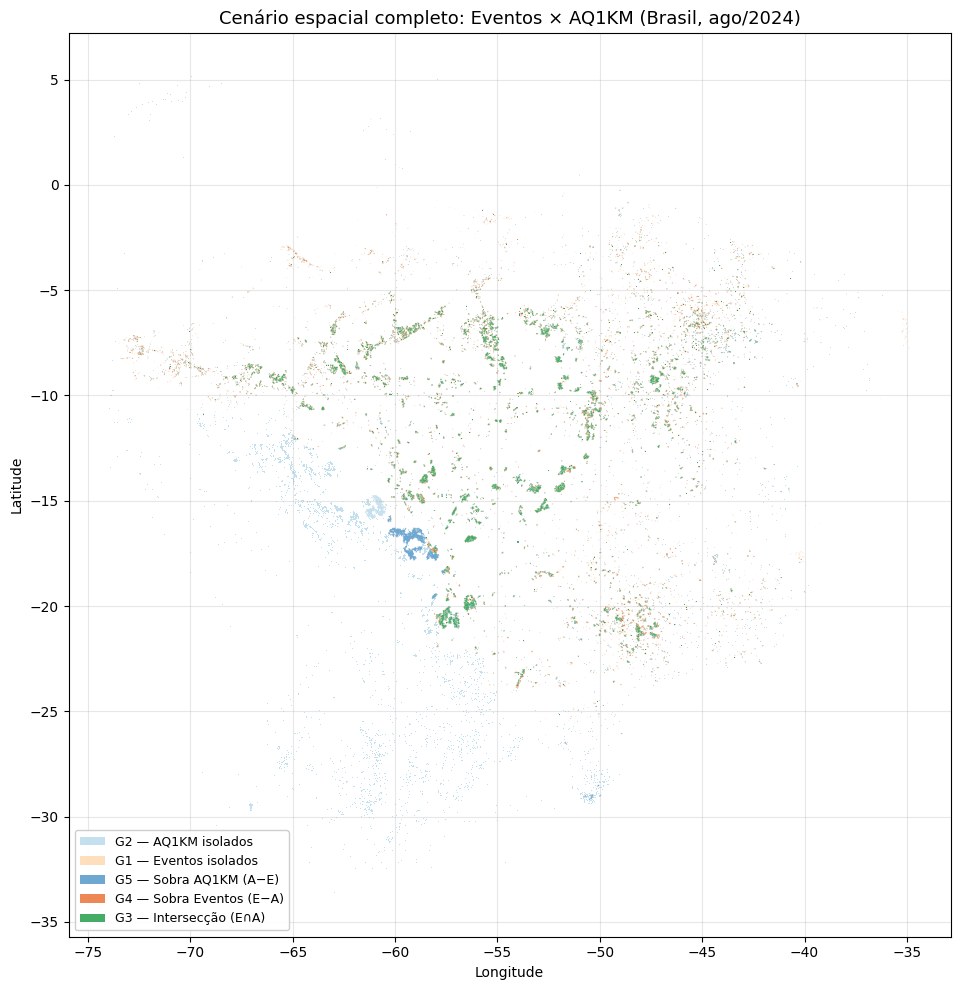

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

# Camadas em ordem (do fundo para frente)
layers = [
    (G2_aq1km_isolados.to_crs(GEO_CRS), '#9ecae1', 'G2 — AQ1KM isolados', 0.6),
    (G1_eventos_isolados.to_crs(GEO_CRS), '#fdd0a2', 'G1 — Eventos isolados', 0.7),
    (G5_sobra_aq1km.to_crs(GEO_CRS),     '#3182bd', 'G5 — Sobra AQ1KM (A−E)', 0.7),
    (G4_sobra_eventos.to_crs(GEO_CRS),   '#e6550d', 'G4 — Sobra Eventos (E−A)', 0.7),
    (G3_interseccao.to_crs(GEO_CRS),     '#31a354', 'G3 — Intersecção (E∩A)', 0.9),
]

for gdf, color, _, alpha in layers:
    if len(gdf):
        gdf.plot(ax=ax, color=color, alpha=alpha, linewidth=0)

handles = [Patch(facecolor=c, label=lab, alpha=a) for _, c, lab, a in layers]
ax.legend(handles=handles, loc='lower left', fontsize=9, framealpha=0.95)
ax.set_title('Cenário espacial completo: Eventos × AQ1KM (Brasil, ago/2024)',
             fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Gráfico de barras com a contribuição de cada grupo:

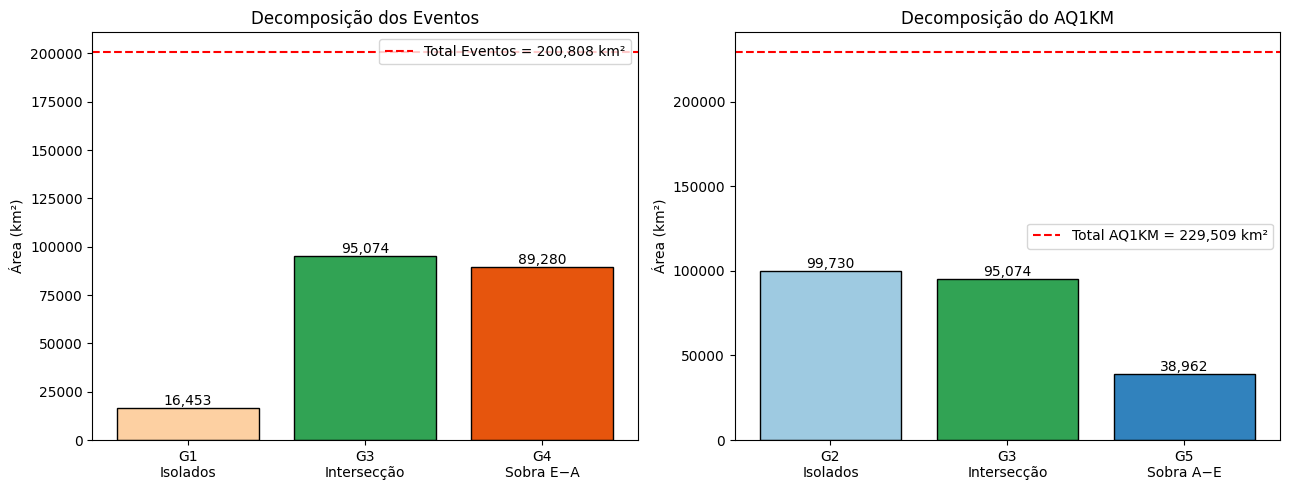

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel 1: contribuição para Eventos
labels_E = ['G1\nIsolados', 'G3\nIntersecção', 'G4\nSobra E−A']
vals_E   = [area_G1/1e6, area_G3/1e6, area_G4/1e6]
colors_E = ['#fdd0a2', '#31a354', '#e6550d']
axes[0].bar(labels_E, vals_E, color=colors_E, edgecolor='black')
axes[0].axhline(area_E_total/1e6, color='red', linestyle='--',
                label=f'Total Eventos = {area_E_total/1e6:,.0f} km²')
axes[0].set_title('Decomposição dos Eventos')
axes[0].set_ylabel('Área (km²)')
axes[0].legend()
for i, v in enumerate(vals_E):
    axes[0].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

# Painel 2: contribuição para AQ1KM
labels_A = ['G2\nIsolados', 'G3\nIntersecção', 'G5\nSobra A−E']
vals_A   = [area_G2/1e6, area_G3/1e6, area_G5/1e6]
colors_A = ['#9ecae1', '#31a354', '#3182bd']
axes[1].bar(labels_A, vals_A, color=colors_A, edgecolor='black')
axes[1].axhline(area_A_total/1e6, color='red', linestyle='--',
                label=f'Total AQ1KM = {area_A_total/1e6:,.0f} km²')
axes[1].set_title('Decomposição do AQ1KM')
axes[1].set_ylabel('Área (km²)')
axes[1].legend()
for i, v in enumerate(vals_A):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## FASE 6 — Operações de Conjunto (Itens 14–18)

Operações teóricas de conjuntos sobre as **uniões** das duas camadas:
$A = E^\cup$ (união dos eventos), $B = A^\cup$ (união do AQ1KM).

In [18]:
# A = união de Eventos, B = união de AQ1KM
A_geom = ev_union
B_geom = aq_union

# 14. Intersecção
inter_AB = A_geom.intersection(B_geom)
# 15. União
union_AB = A_geom.union(B_geom)
# 16. Diferença A - B
diff_AB = A_geom.difference(B_geom)
# 17. Diferença B - A
diff_BA = B_geom.difference(A_geom)
# 18. Diferença simétrica A △ B
sym_AB = A_geom.symmetric_difference(B_geom)

operacoes = pd.DataFrame([
    {'Operacao':'14. Intersecção (A ∩ B)',          'Area_km2': inter_AB.area/1e6},
    {'Operacao':'15. União (A ∪ B)',                'Area_km2': union_AB.area/1e6},
    {'Operacao':'16. Diferença (A − B)',            'Area_km2': diff_AB.area/1e6},
    {'Operacao':'17. Diferença (B − A)',            'Area_km2': diff_BA.area/1e6},
    {'Operacao':'18. Diferença simétrica (A △ B)',  'Area_km2': sym_AB.area/1e6},
])
operacoes

,Operacao,Area_km2
0,14. Intersecção (A ∩ B),"90,817.4162"
1,15. União (A ∪ B),"331,632.5797"
2,16. Diferença (A − B),"102,123.7628"
3,17. Diferença (B − A),"138,691.4007"
4,18. Diferença simétrica (A △ B),"240,815.1635"


### 6.1 Identidades de verificação

Sanidade matemática:

- $A \cup B = (A \cap B) + (A - B) + (B - A)$
- $A \triangle B = (A - B) \cup (B - A) = (A \cup B) - (A \cap B)$

In [19]:
ident_1 = (inter_AB.area + diff_AB.area + diff_BA.area)
ident_2 = sym_AB.area
ident_3 = union_AB.area - inter_AB.area

print('Identidade 1: A∪B = (A∩B) + (A−B) + (B−A)')
print(f'  A∪B            = {union_AB.area/1e6:,.4f} km²')
print(f'  soma das partes = {ident_1/1e6:,.4f} km²')
print(f'  diferença       = {(union_AB.area - ident_1)/1e6:,.6f} km²')
print()
print('Identidade 2: A△B = (A∪B) − (A∩B)')
print(f'  A△B             = {ident_2/1e6:,.4f} km²')
print(f'  A∪B − A∩B       = {ident_3/1e6:,.4f} km²')
print(f'  diferença       = {(ident_2 - ident_3)/1e6:,.6f} km²')

Identidade 1: A∪B = (A∩B) + (A−B) + (B−A)
  A∪B            = 331,632.5797 km²
  soma das partes = 331,632.5797 km²
  diferença       = 0.000000 km²

Identidade 2: A△B = (A∪B) − (A∩B)
  A△B             = 240,815.1635 km²
  A∪B − A∩B       = 240,815.1635 km²
  diferença       = 0.000000 km²


### 6.2 Visualização das operações de conjunto

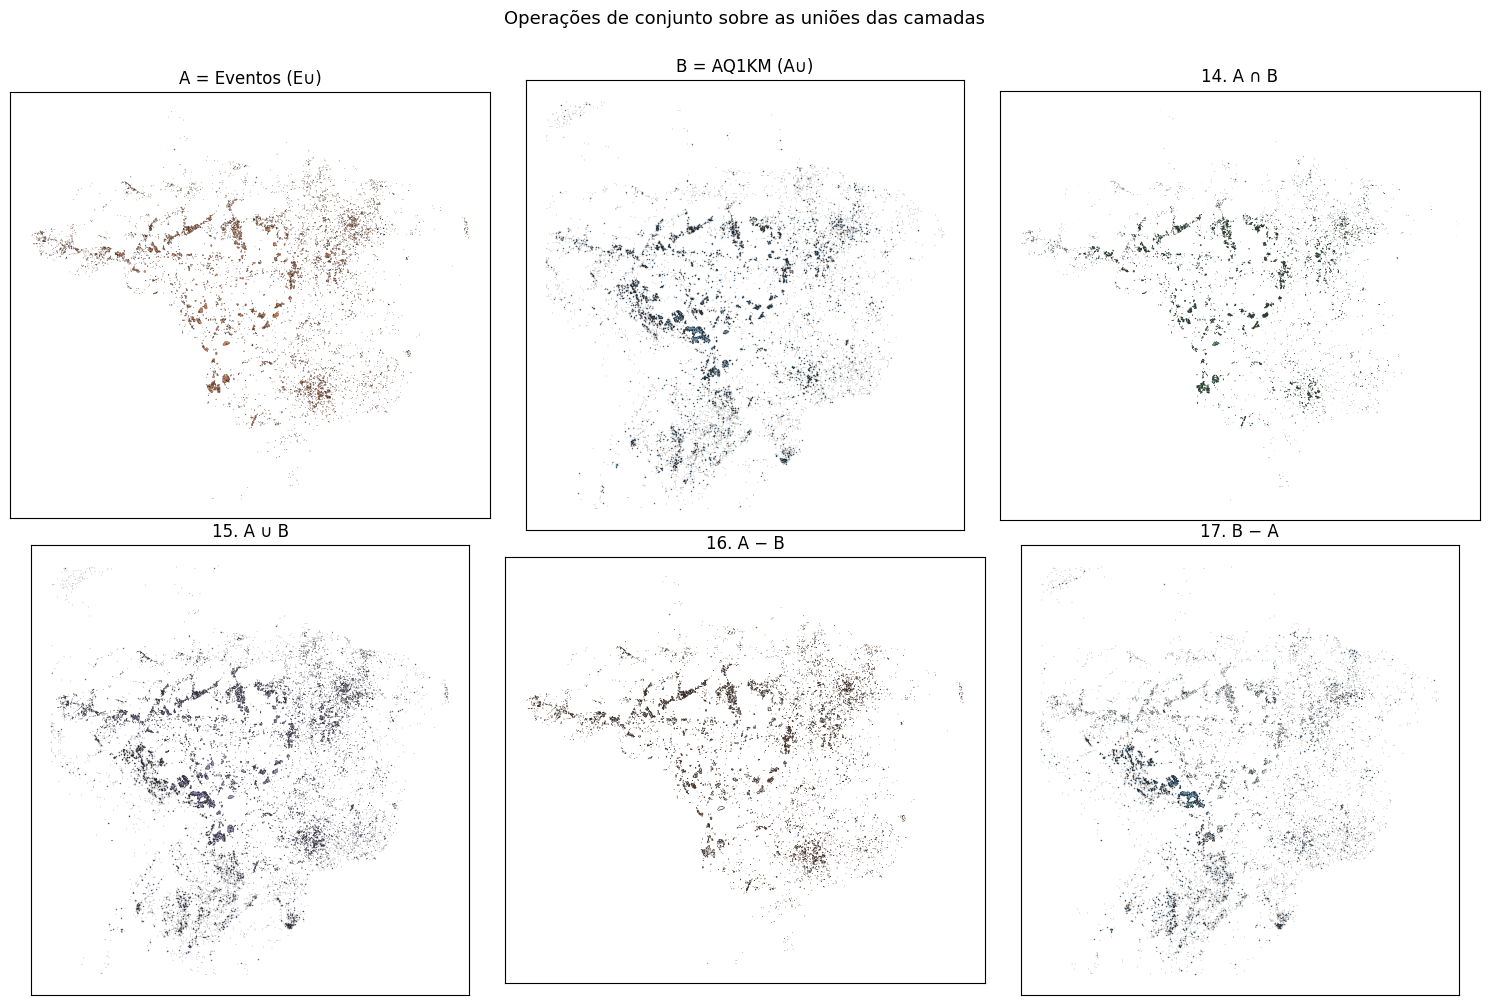

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Para visualização, convertemos cada geometria em GeoDataFrame em EPSG:4326
def to_gdf(geom):
    if geom.is_empty:
        return gpd.GeoDataFrame(geometry=[], crs=EQ_CRS).to_crs(GEO_CRS)
    return gpd.GeoDataFrame(geometry=[geom], crs=EQ_CRS).to_crs(GEO_CRS)

A_gdf = to_gdf(A_geom)
B_gdf = to_gdf(B_geom)

painels = [
    ('A = Eventos (E∪)',          A_gdf,           '#e6550d'),
    ('B = AQ1KM (A∪)',            B_gdf,           '#3182bd'),
    ('14. A ∩ B',                 to_gdf(inter_AB),'#31a354'),
    ('15. A ∪ B',                 to_gdf(union_AB),'#756bb1'),
    ('16. A − B',                 to_gdf(diff_AB), '#e6550d'),
    ('17. B − A',                 to_gdf(diff_BA), '#3182bd'),
]

for ax, (titulo, gdf, cor) in zip(axes, painels):
    if len(gdf):
        gdf.plot(ax=ax, color=cor, alpha=0.7, edgecolor='black', linewidth=0.2)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Operações de conjunto sobre as uniões das camadas', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

## FASE 7 — Exportação dos Resultados (opcional)

Exportamos cada grupo como GeoPackage para uso posterior em GIS.

In [21]:
import os
OUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

GPKG = os.path.join(OUT_DIR, 'analise_espacial_eventos_aq1km.gpkg')

# Reprojetar para EPSG:4326 ao salvar (compatibilidade ampla)
G1_eventos_isolados.to_crs(GEO_CRS).to_file(GPKG, layer='G1_eventos_isolados', driver='GPKG')
G2_aq1km_isolados.to_crs(GEO_CRS).to_file(GPKG, layer='G2_aq1km_isolados', driver='GPKG')
G3_interseccao.to_crs(GEO_CRS).to_file(GPKG, layer='G3_interseccao', driver='GPKG')
G4_sobra_eventos.to_crs(GEO_CRS).to_file(GPKG, layer='G4_sobra_eventos', driver='GPKG')
G5_sobra_aq1km.to_crs(GEO_CRS).to_file(GPKG, layer='G5_sobra_aq1km', driver='GPKG')

# Tabela-resumo em CSV
resumo_final.to_csv(os.path.join(OUT_DIR, 'resumo_areas.csv'))

print(f'GeoPackage salvo em: {GPKG}')
print(f'Resumo CSV salvo em: {os.path.join(OUT_DIR, "resumo_areas.csv")}')

GeoPackage salvo em: /mnt/user-data/outputs/analise_espacial_eventos_aq1km.gpkg
Resumo CSV salvo em: /mnt/user-data/outputs/resumo_areas.csv


## Conclusão

✅ **100% do cenário espacial foi mapeado** entre Eventos e AQ1KM.

✅ **Conservação de área verificada:**
- Eventos = G1 + G3 + G4 (exato)
- AQ1KM = G2 + G3 + G5 (exato na versão estrita)

✅ Os cinco grupos cobrem todas as combinações topológicas possíveis:
isolados de cada lado, núcleo da sobreposição, e as duas sobras.

✅ Operações de conjunto (intersecção, união, diferenças, diferença simétrica)
calculadas e validadas pelas identidades matemáticas.

### Arquivos gerados
- `analise_espacial_eventos_aq1km.gpkg` — todos os 5 grupos como camadas
- `resumo_areas.csv` — tabela final de áreas